In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import joblib

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB , GaussianNB , MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , StandardScaler , OrdinalEncoder , MinMaxScaler
from sklearn.metrics  import  accuracy_score , confusion_matrix , f1_score , precision_score , recall_score
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/bank_loan_classification_dataset.csv")

In [4]:
df.head()

,customer_id,age,gender,region,marital_status,education_level,employment_type,annual_income_lakh,credit_score,years_employed,existing_loans,debt_to_income_ratio,loan_amount_lakh,interest_rate_percent,missed_payments,savings_balance_lakh,loan_purpose,loan_approved
0,CUST000001,59,Male,North,Single,Bachelor,Business,9.25,721,7,4,37.83,7.67,13.35,4,7.26,Car,0
1,CUST000002,56,Male,North,Single,High School,Student,13.96,605,1,3,56.62,26.70,6.11,8,17.23,Home,0
2,CUST000003,47,Male,South,Married,Bachelor,Salaried,6.94,705,27,3,25.15,26.73,9.19,6,6.65,Personal,0
3,CUST000004,23,Male,West,Married,High School,Business,14.09,746,8,1,57.19,10.19,16.95,6,6.25,Car,0
4,CUST000005,28,Female,East,Single,Bachelor,Self-Employed,16.11,582,1,5,33.60,4.37,21.51,9,9.18,Education,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            22000 non-null  object 
 1   age                    22000 non-null  int64  
 2   gender                 22000 non-null  object 
 3   region                 22000 non-null  object 
 4   marital_status         22000 non-null  object 
 5   education_level        22000 non-null  object 
 6   employment_type        22000 non-null  object 
 7   annual_income_lakh     22000 non-null  float64
 8   credit_score           22000 non-null  int64  
 9   years_employed         22000 non-null  int64  
 10  existing_loans         22000 non-null  int64  
 11  debt_to_income_ratio   22000 non-null  float64
 12  loan_amount_lakh       22000 non-null  float64
 13  interest_rate_percent  22000 non-null  float64
 14  missed_payments        22000 non-null  int64  
 15  sa

In [6]:
df.isna().sum()

,0
customer_id,0
age,0
gender,0
region,0
marital_status,0
education_level,0
employment_type,0
annual_income_lakh,0
credit_score,0
years_employed,0


In [7]:
df.describe()

,age,annual_income_lakh,credit_score,years_employed,existing_loans,debt_to_income_ratio,loan_amount_lakh,interest_rate_percent,missed_payments,savings_balance_lakh,loan_approved
count,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000,22000.000000
mean,40.451864,12.037691,680.472136,17.052364,2.499318,32.557643,15.103424,14.011815,4.522864,8.176522,0.231591
std,11.548889,4.918078,80.114691,10.078260,1.716113,15.849679,7.715814,4.633025,2.868930,5.504690,0.421859
min,21.000000,2.000000,364.000000,0.000000,0.000000,5.000000,1.000000,6.000000,0.000000,0.000000,0.000000
25%,30.000000,8.640000,625.000000,8.000000,1.000000,18.877500,9.540000,9.970000,2.000000,3.890000,0.000000
50%,40.000000,12.000000,680.000000,17.000000,2.000000,32.545000,15.010000,14.030000,5.000000,7.930000,0.000000
75%,50.000000,15.370000,735.000000,26.000000,4.000000,46.232500,20.410000,18.060000,7.000000,11.930000,0.000000
max,60.000000,30.990000,900.000000,34.000000,5.000000,60.000000,48.180000,22.000000,9.000000,29.370000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='annual_income_lakh', ylabel='Count'>

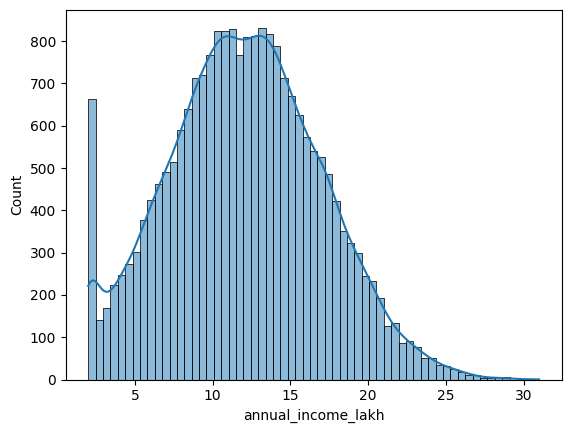

In [9]:
sns.histplot(df["annual_income_lakh"],kde = True)

<Axes: xlabel='credit_score', ylabel='Count'>

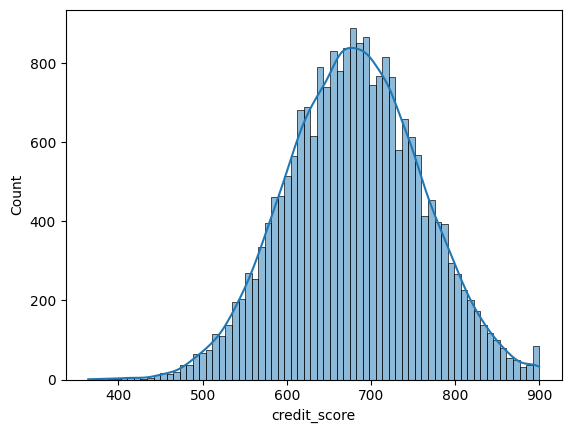

In [10]:
sns.histplot(df["credit_score"],kde = True)

In [11]:
feature = ["annual_income_lakh","credit_score",	"years_employed","existing_loans","loan_approved"]

<Figure size 1600x900 with 0 Axes>

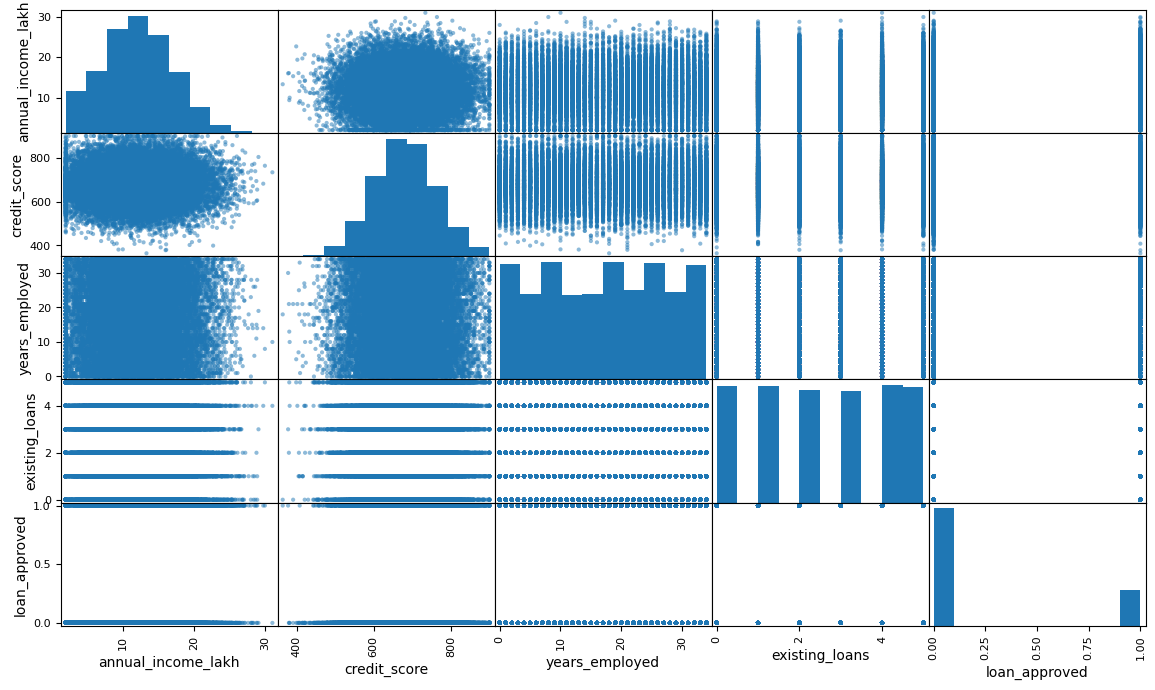

In [12]:
plt.figure(figsize=(16,9))
scatter_matrix(df[feature],figsize=(14, 8))
plt.show()

<Axes: >

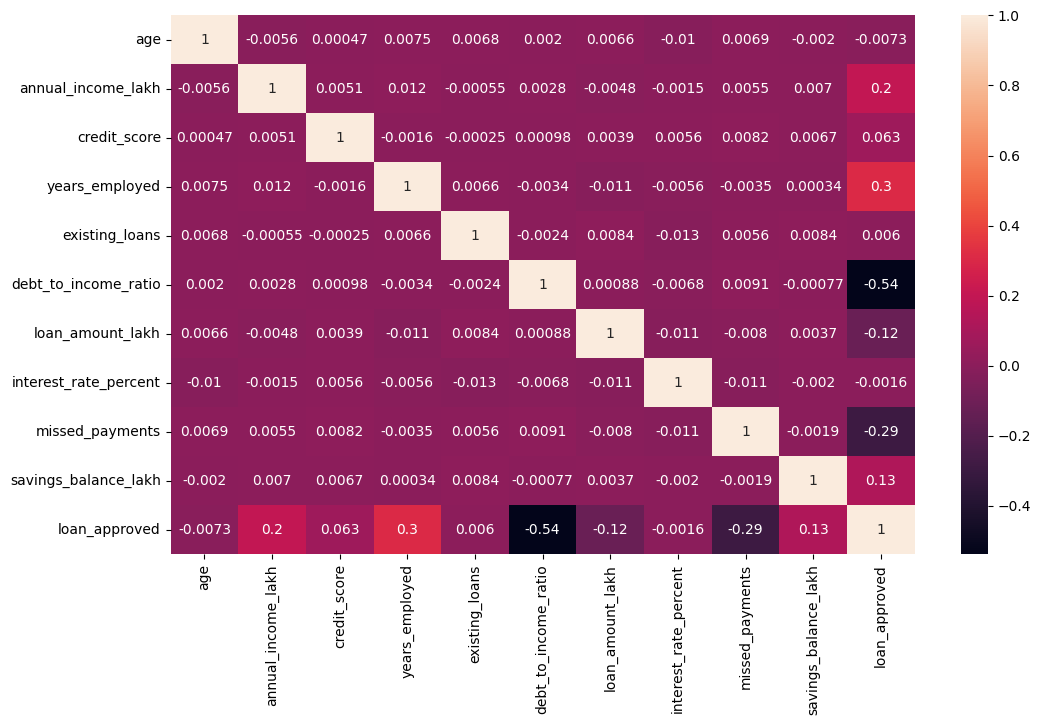

In [13]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(12,7))
sns.heatmap(correlation,annot=True)

---
Outlier Detection
---
---

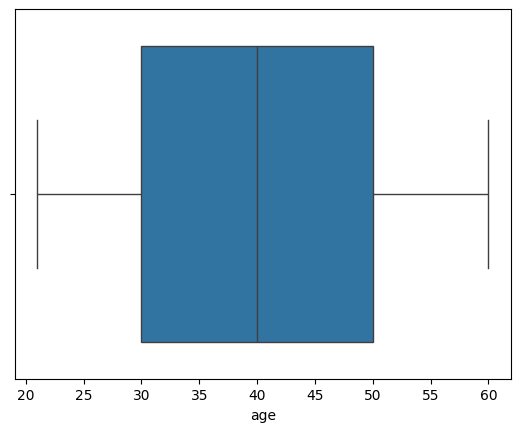

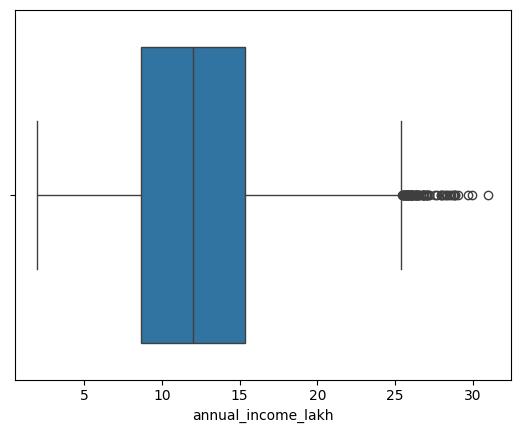

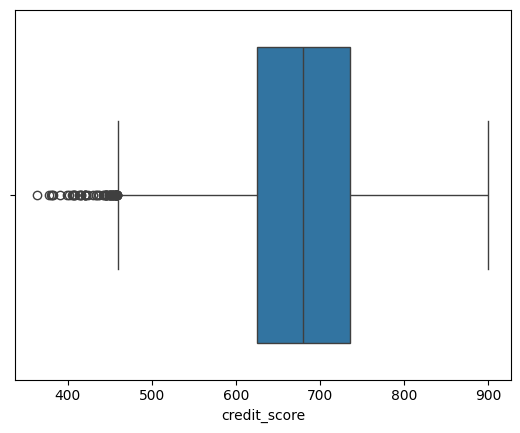

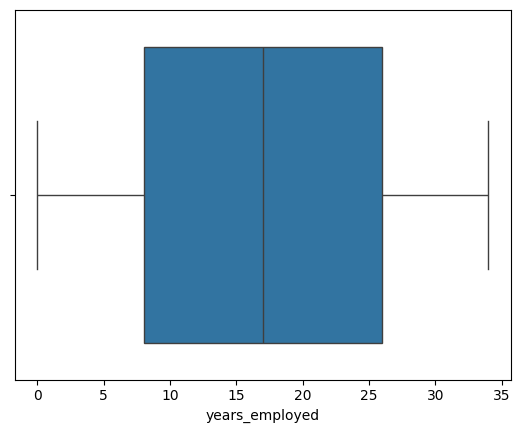

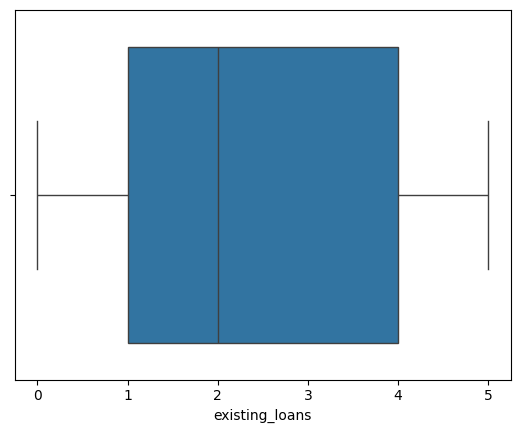

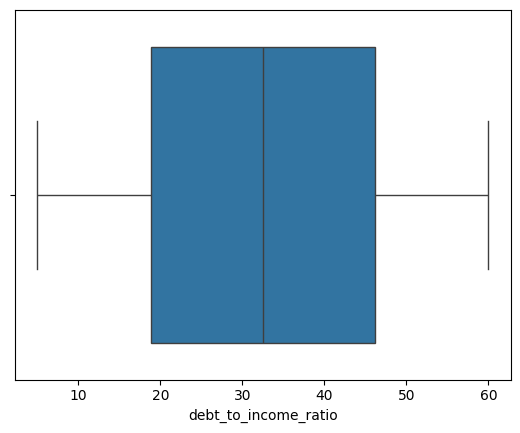

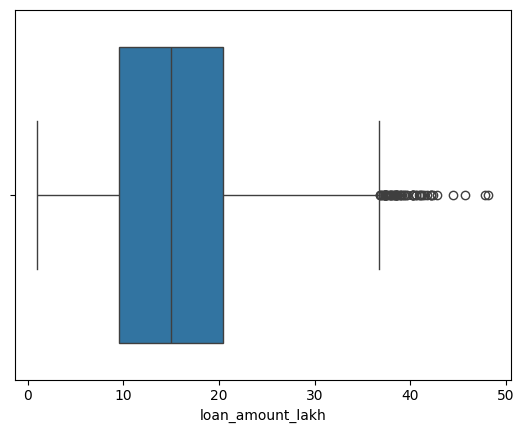

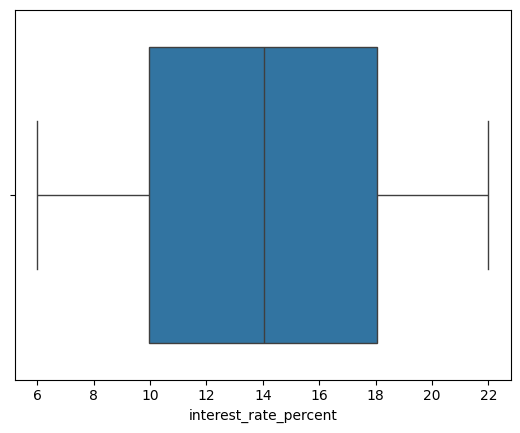

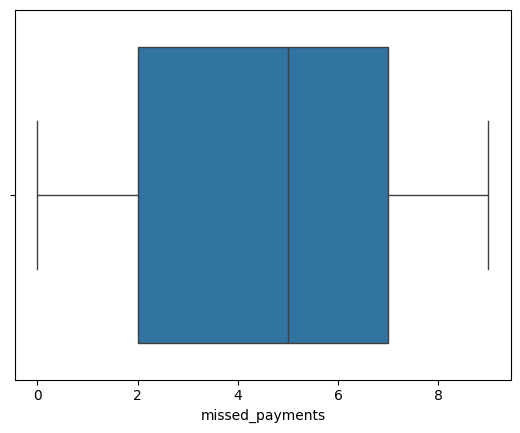

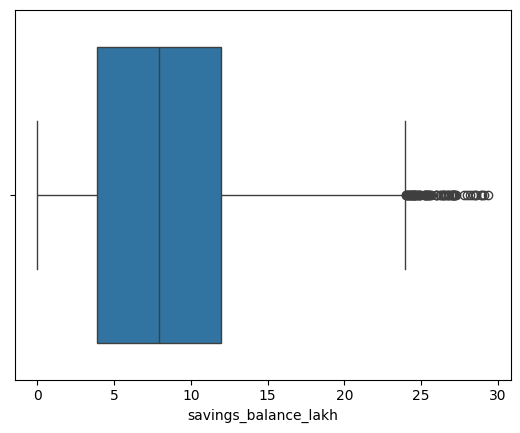

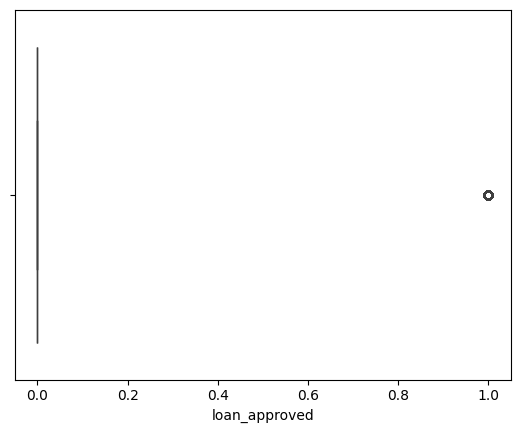

In [14]:
col=[x for x in df.columns if df[x].dtypes==int or df[x].dtypes==float]

for i in col:
  sns.boxplot(x = df[i])
  plt.show()

In [15]:
col = ["annual_income_lakh","credit_score","loan_amount_lakh"]

for i in col:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)

  iqr = q3 - q1

  lower = q1 - (iqr*1.5)
  upper = q3 + (iqr*1.5)

  df = df[(df[i] > lower) & (df[i] < upper)]

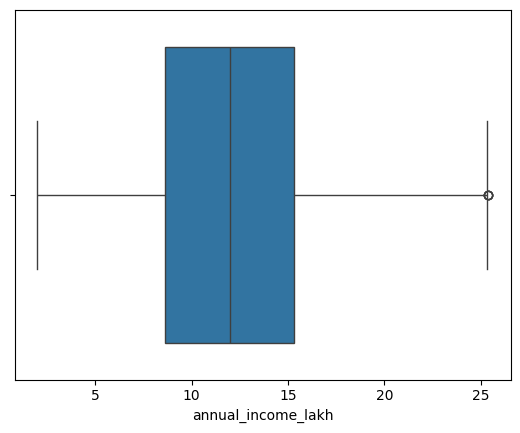

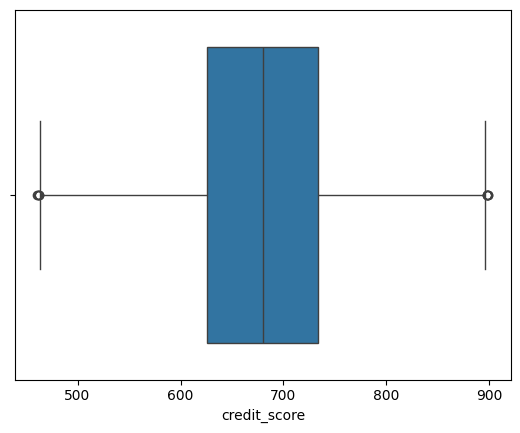

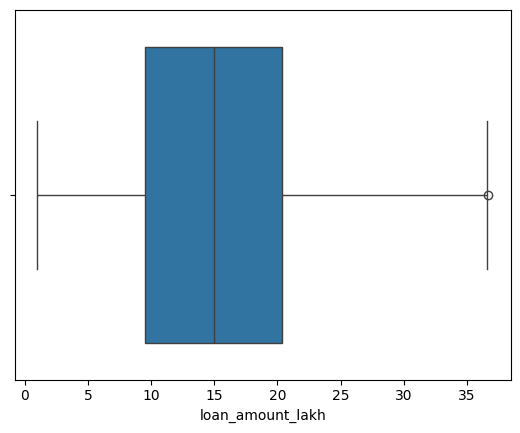

In [16]:
col = ["annual_income_lakh","credit_score","loan_amount_lakh"]

for i in col:
  sns.boxplot(x = df[i])
  plt.show()

In [17]:
x = df.drop(["customer_id","region","loan_approved"],axis = 1)
y = df["loan_approved"]

In [18]:
df.select_dtypes(include="object")

,customer_id,gender,region,marital_status,education_level,employment_type,loan_purpose
0,CUST000001,Male,North,Single,Bachelor,Business,Car
1,CUST000002,Male,North,Single,High School,Student,Home
2,CUST000003,Male,South,Married,Bachelor,Salaried,Personal
3,CUST000004,Male,West,Married,High School,Business,Car
4,CUST000005,Female,East,Single,Bachelor,Self-Employed,Education
...,...,...,...,...,...,...,...
21994,CUST021995,Male,North,Married,PhD,Salaried,Business
21995,CUST021996,Female,South,Single,Bachelor,Business,Business
21996,CUST021997,Male,West,Single,Master,Business,Business
21998,CUST021999,Female,South,Married,PhD,Business,Car


---
# Feature Engineering
---

In [19]:
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # Loan Income Ratio
        X["loan_income_ratio"] = (
            X["loan_amount_lakh"]
            /
            (X["annual_income_lakh"] + 1)
        )

        # Financial Stability Score
        X["financial_stability_score"] = (
            (X["credit_score"] * 0.5)
            +
            (X["savings_balance_lakh"] * 10)
            -
            (X["missed_payments"] * 5)
        )

        # Debt Burden Score
        X["debt_burden_score"] = (
            X["debt_to_income_ratio"]
            *
            (X["existing_loans"] + 1)
        )

        return X

In [20]:
numerical_feature = x.select_dtypes(exclude="object").columns
ordinal_feature = ["education_level"]
categorical_feature = ["gender","marital_status","employment_type","loan_purpose"]


numerical_preprocessing = Pipeline(
    steps = [
        ("Imputer",SimpleImputer(strategy="median")),
        ("Standard_Scaler",MinMaxScaler())
    ]
)

ordinal_preprocessing = Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="most_frequent")),
        ("Ordinal",OrdinalEncoder(categories=[["High School","Bachelor","Master","PhD"]]))
    ]
)

categorical_preprocessing = Pipeline(
    steps=[
        ("Imputer",SimpleImputer(strategy="most_frequent")),
        ("Label_encoder",OrdinalEncoder())
    ]
)

preprocessing  = ColumnTransformer(
    transformers=[
        ("Numerical_Pre",numerical_preprocessing,numerical_feature),
        ("Ordinal_Pre",ordinal_preprocessing,ordinal_feature),
        ("Label_Pre",categorical_preprocessing,categorical_feature),
    ]
)

---
Train - Test Split

In [21]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=.25,random_state=42)
print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)


Training Shape: (16298, 15)
Testing Shape: (5433, 15)


---
# ML MODELS
---

In [22]:
lr_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ("Preprocessing",preprocessing),
        ("Logistic",LogisticRegression())
    ]
)

In [23]:
knn_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ("Preprocessing",preprocessing),
        ("KNN",KNeighborsClassifier(n_neighbors=3))
    ]
)

In [24]:
bernoli_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ("Preprocessing",preprocessing),
        ("bernoli_model",BernoulliNB())
    ]
)

In [25]:
gaussian_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ("Preprocessing",preprocessing),
        ("gaussian_model",GaussianNB())
    ]
)



In [26]:
multinomial_model = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineer()),
        ("Preprocessing",preprocessing),
        ("multinomial_model",MultinomialNB())
    ]
)

In [27]:
models = {
    'Logistic':lr_model,
    'Knn':knn_model,
    'Bernoli':bernoli_model,
    'Gausian':gaussian_model,
    'Multi':multinomial_model
}

for name , model in models.items():
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)

  print("-------------------------------------")
  print(f"{name} Metrix Evaluation")

  print("Accuracy Score : ",accuracy_score(y_test,y_pred))
  print("Confussion Metrix")
  print(confusion_matrix(y_test,y_pred))
  print("Precision :",precision_score(y_test,y_pred,zero_division=0))
  print("Recall :",recall_score(y_test,y_pred,zero_division=0))
  print("F1_Score :",f1_score(y_test,y_pred,zero_division=0))
  print()

-------------------------------------
Logistic Metrix Evaluation
Accuracy Score :  0.9937419473587337
Confussion Metrix
[[4126    0]
 [  34 1273]]
Precision : 1.0
Recall : 0.9739862280030605
F1_Score : 0.9868217054263566

-------------------------------------
Knn Metrix Evaluation
Accuracy Score :  0.8221976808393153
Confussion Metrix
[[3892  234]
 [ 732  575]]
Precision : 0.7107540173053152
Recall : 0.43993879112471307
F1_Score : 0.5434782608695652

-------------------------------------
Bernoli Metrix Evaluation
Accuracy Score :  0.7609055770292656
Confussion Metrix
[[4118    8]
 [1291   16]]
Precision : 0.6666666666666666
Recall : 0.01224177505738332
F1_Score : 0.02404207362885049

-------------------------------------
Gausian Metrix Evaluation
Accuracy Score :  0.9427572243695932
Confussion Metrix
[[4122    4]
 [ 307 1000]]
Precision : 0.9960159362549801
Recall : 0.7651109410864575
F1_Score : 0.8654262224145391

-------------------------------------
Multi Metrix Evaluation
Accuracy 

In [28]:
x

,age,gender,marital_status,education_level,employment_type,annual_income_lakh,credit_score,years_employed,existing_loans,debt_to_income_ratio,loan_amount_lakh,interest_rate_percent,missed_payments,savings_balance_lakh,loan_purpose
0,59,Male,Single,Bachelor,Business,9.25,721,7,4,37.83,7.67,13.35,4,7.26,Car
1,56,Male,Single,High School,Student,13.96,605,1,3,56.62,26.70,6.11,8,17.23,Home
2,47,Male,Married,Bachelor,Salaried,6.94,705,27,3,25.15,26.73,9.19,6,6.65,Personal
3,23,Male,Married,High School,Business,14.09,746,8,1,57.19,10.19,16.95,6,6.25,Car
4,28,Female,Single,Bachelor,Self-Employed,16.11,582,1,5,33.60,4.37,21.51,9,9.18,Education
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21994,37,Male,Married,PhD,Salaried,5.92,723,19,3,37.88,21.67,19.54,7,12.13,Business
21995,47,Female,Single,Bachelor,Business,10.91,716,8,0,21.11,6.47,10.81,5,11.22,Business
21996,37,Male,Single,Master,Business,16.26,649,16,4,10.08,18.27,20.23,6,18.95,Business
21998,56,Female,Married,PhD,Business,7.93,699,31,2,49.43,6.73,17.02,3,6.03,Car


In [29]:
y_train

,loan_approved
6542,0
3524,0
5361,1
1020,0
11409,0
...,...
12131,0
21840,0
5463,0
868,1


In [30]:
lr_model.fit(x_train,y_train)

Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                ('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical_Pre',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Standard_Scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['age', 'annual_income_lakh', 'credit_score', 'years_employed',
       'existing_loans', 'debt_to_income_ratio', 'loan_amount_lakh',
       'in...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Ordinal',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'PhD']]))]),
                                                  ['education_level']),
                                                 ('Label_Pre',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Label_encoder',
                                                                   OrdinalEncoder())]),
                                                  ['gender', 'marital_status',
                                                   'employment_type',
                                                   'loan_purpose'])])),
                ('Logistic', LogisticRegression())])

In [31]:
joblib.dump(lr_model,"/content/drive/MyDrive/Dataset/model_new.pkl")

['/content/drive/MyDrive/Dataset/model_new.pkl']

In [32]:
import sklearn
print(sklearn.__version__)

1.6.1
